<h1>Содержание<span class="tocSkip"></span></h1><div class="toc"><ul class="toc-item"><li><span><a href="#1.-Подготовка" data-toc-modified-id="1.-Подготовка-1">1. Подготовка</a></span></li><ul class="toc-item"><li><span><a href="#1.1.-Импорт-библиотек-и-настройка-окружения" data-toc-modified-id="1.1.-Импорт-библиотек-и-настройка-окружения-2">1.1. Импорт библиотек и настройка окружения</a></span></li><li><span><a href="#1.2.-Загрузка-данных" data-toc-modified-id="1.2.-Загрузка-данных-3">1.2. Загрузка данных</a></span></li><li><span><a href="#1.3.-Исследовательский-анализ-данных" data-toc-modified-id="1.3.-Исследовательский-анализ-данных-4">1.3. Исследовательский анализ данных</a></span></li><li><span><a href="#1.4.-Формирование-подвыборки-и-разбиение-данных" data-toc-modified-id="1.4.-Формирование-подвыборки-и-разбиение-данных-5">1.4. Формирование подвыборки и разбиение данных</a></span></li><li><span><a href="#1.5.-Предобработка-текста-для-классических-моделей" data-toc-modified-id="1.5.-Предобработка-текста-для-классических-моделей-6">1.5. Предобработка текста для классических моделей</a></span></li><li><span><a href="#1.6.-Выбор-длины-последовательности-для-BERT" data-toc-modified-id="1.6.-Выбор-длины-последовательности-для-BERT-7">1.6. Выбор длины последовательности для BERT</a></span></li><li><span><a href="#Итоги-подготовки-данных" data-toc-modified-id="Итоги-подготовки-данных-8">Итоги подготовки данных</a></span></li></ul></li><li><span><a href="#2.-Обучение" data-toc-modified-id="2.-Обучение-9">2. Обучение</a></span></li><ul class="toc-item"><li><span><a href="#2.1.-Метрика-и-протокол-сравнения" data-toc-modified-id="2.1.-Метрика-и-протокол-сравнения-10">2.1. Метрика и протокол сравнения</a></span></li><li><span><a href="#2.2.-Константная-модель" data-toc-modified-id="2.2.-Константная-модель-11">2.2. Константная модель</a></span></li><li><span><a href="#2.3.-Признаки-TF-IDF" data-toc-modified-id="2.3.-Признаки-TF-IDF-12">2.3. Признаки TF-IDF</a></span></li><li><span><a href="#2.4.-Логистическая-регрессия-на-TF-IDF" data-toc-modified-id="2.4.-Логистическая-регрессия-на-TF-IDF-13">2.4. Логистическая регрессия на TF-IDF</a></span></li><li><span><a href="#2.5.-Линейный-SVM-на-TF-IDF" data-toc-modified-id="2.5.-Линейный-SVM-на-TF-IDF-14">2.5. Линейный SVM на TF-IDF</a></span></li><li><span><a href="#2.6.-Градиентный-бустинг-на-TF-IDF" data-toc-modified-id="2.6.-Градиентный-бустинг-на-TF-IDF-15">2.6. Градиентный бустинг на TF-IDF</a></span></li><li><span><a href="#2.7.-Дообучение-DistilBERT" data-toc-modified-id="2.7.-Дообучение-DistilBERT-16">2.7. Дообучение DistilBERT</a></span></li><li><span><a href="#2.8.-Дообучение-BERT-base" data-toc-modified-id="2.8.-Дообучение-BERT-base-17">2.8. Дообучение BERT-base</a></span></li><li><span><a href="#2.9.-Сравнение-моделей-на-валидации" data-toc-modified-id="2.9.-Сравнение-моделей-на-валидации-18">2.9. Сравнение моделей на валидации</a></span></li><li><span><a href="#Итоги-обучения" data-toc-modified-id="Итоги-обучения-19">Итоги обучения</a></span></li></ul></li><li><span><a href="#3.-Тестирование" data-toc-modified-id="3.-Тестирование-20">3. Тестирование</a></span></li><ul class="toc-item"><li><span><a href="#Сохранение-модели" data-toc-modified-id="Сохранение-модели-21">Сохранение модели</a></span></li><li><span><a href="#Итоги-тестирования" data-toc-modified-id="Итоги-тестирования-22">Итоги тестирования</a></span></li></ul></li><li><span><a href="#4.-Выводы" data-toc-modified-id="4.-Выводы-23">4. Выводы</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-24">Чек-лист проверки</a></span></li></ul></div>

# Проект для «Викишоп» с BERT

Интернет-магазин «Викишоп» запускает сервис, в котором пользователи сами редактируют и дополняют
описания товаров, как в вики-сообществах. Клиенты предлагают правки и комментируют изменения
других, поэтому магазину нужен инструмент, который будет находить токсичные комментарии
и отправлять их на модерацию.

**Задача:** обучить модель классифицировать комментарии на позитивные и негативные.

**Целевая метрика:** *F1* не меньше **0.75** по классу «токсичный».

**Данные:** файл `toxic_comments.csv`, столбец `text` - текст комментария, `toxic` - целевой признак.

**План работы**

1. **Подготовка.** Загрузим данные, проведём исследовательский анализ, сформируем подвыборку,
   разобьём её на обучающую, валидационную и тестовую части и подготовим два представления текста:
   лемматизированное - для классических моделей, исходное - для BERT.
2. **Обучение.** Сравним константную модель, три модели поверх TF-IDF (логистическая регрессия,
   `LinearSVC`, `LightGBM`) и дообученные трансформеры (`DistilBERT` и `BERT-base`).
   Гиперпараметры всех моделей подбираем на валидационной выборке.
3. **Тестирование.** Лучшую по валидации модель проверим на отложенной тестовой выборке.
4. **Выводы.**

## 1. Подготовка

### 1.1. Импорт библиотек и настройка окружения

In [1]:
# библиотеки Hugging Face печатают при загрузке моделей служебные отчёты и полосы прогресса,
# которые не несут полезной информации; переменные окружения нужно задать до их импорта
import os

os.environ["HF_HUB_VERBOSITY"] = "error"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

In [2]:
import gc
import json
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import transformers

from IPython.display import display
from lightgbm import LGBMClassifier
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.svm import LinearSVC
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

warnings.simplefilter("ignore")
transformers.logging.set_verbosity_error()
transformers.utils.logging.disable_progress_bar()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
SAMPLE_SIZE = 50_000     # размер подвыборки для обучения
MAX_LEN = 192            # длина последовательности для BERT в токенах, обоснование - в п. 1.6
DATA_PATH = "datasets/toxic_comments.csv"

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("устройство:", DEVICE, "|",
      torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "GPU недоступен")

torch: 2.12.1+cu126
устройство: cuda | NVIDIA GeForce RTX 2060 SUPER


In [3]:
# ресурсы NLTK: стоп-слова, словарь WordNet и POS-теггер для лемматизации
for package in ["stopwords", "wordnet", "omw-1.4", "averaged_perceptron_tagger_eng"]:
    nltk.download(package, quiet=True)

### 1.2. Загрузка данных

In [4]:
data = pd.read_csv(DATA_PATH)
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, jus...",0
1,1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and ...",0
3,3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on,...",0
4,4,"You, sir, are my hero. Any chance you remember what page that's on?",0


В таблице три столбца, пропусков нет. Столбец `Unnamed: 0` - служебный: это индекс,
сохранённый при выгрузке файла. Проверим, можно ли удалить его без потери информации.

In [5]:
index_col = data.columns[0]
print("диапазон значений:", data[index_col].min(), "-", data[index_col].max())
print("количество строк:", len(data))
print("значения уникальны:", data[index_col].is_unique)
print("значения упорядочены:", data[index_col].is_monotonic_increasing)
print("пропущено значений в нумерации:",
      data[index_col].max() - data[index_col].min() + 1 - len(data))

диапазон значений: 0 - 159450
количество строк: 159292
значения уникальны: True
значения упорядочены: True
пропущено значений в нумерации: 159


Столбец - упорядоченная сквозная нумерация со 159 пропусками: из исходного датасета удалили
часть строк, а индекс не пересчитали. Полезной информации он не несёт, удаляем.

In [6]:
data = data.drop(columns=[index_col])

print("пропусков:", data.isna().sum().sum())
print("полных дубликатов:", data.duplicated().sum())
print("дубликатов по тексту:", data.duplicated(subset="text").sum())
print("пустых строк после удаления пробелов:", (data["text"].str.strip().str.len() == 0).sum())
print("размер таблицы:", data.shape)

пропусков: 0
полных дубликатов: 0


дубликатов по тексту:

 0
пустых строк после удаления пробелов: 0
размер таблицы: (159292, 2)


Пропусков, дубликатов и пустых строк нет - чистить нечего.

### 1.3. Исследовательский анализ данных

**Баланс классов.** Целевой признак бинарный, посмотрим, насколько он несбалансирован.

       количество    доля
toxic                    
0          143106  0.8984
1           16186  0.1016


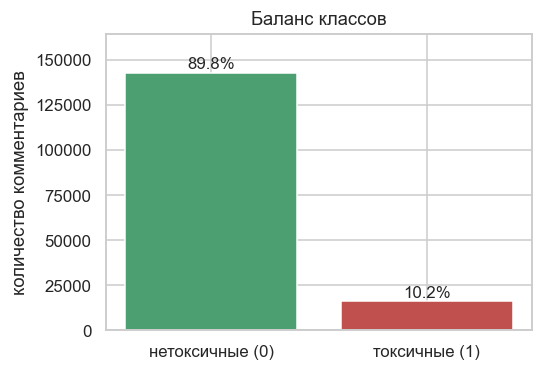

In [7]:
target_counts = data["toxic"].value_counts().sort_index()
target_share = data["toxic"].value_counts(normalize=True).sort_index()
print(pd.DataFrame({"количество": target_counts, "доля": target_share.round(4)}))

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(["нетоксичные (0)", "токсичные (1)"], target_counts,
              color=["#4c9f70", "#c0504d"])
for bar, share in zip(bars, target_share):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f"{share:.1%}", ha="center", fontsize=11)
ax.set_title("Баланс классов")
ax.set_ylabel("количество комментариев")
ax.set_ylim(0, target_counts.max() * 1.15)
plt.show()

Классы сильно несбалансированы: токсичных комментариев около 10%. Отсюда два следствия:

* доля правильных ответов (*accuracy*) как метрика бесполезна - константный ответ «не токсичный»
  даст около 0.90, поэтому и требуется *F1* по положительному классу;
* при обучении понадобится либо взвешивание классов, либо подбор порога классификации.

**Длина комментариев.** От неё зависят выбор `max_length` для BERT и стоимость обучения.

          count  mean    std  min   50%    90%    99%     max
toxic                                                        
0      143106.0  68.9   98.1  1.0  37.0  156.0  562.0  1250.0
1       16186.0  52.7  106.8  1.0  23.0  106.0  654.4  1411.0


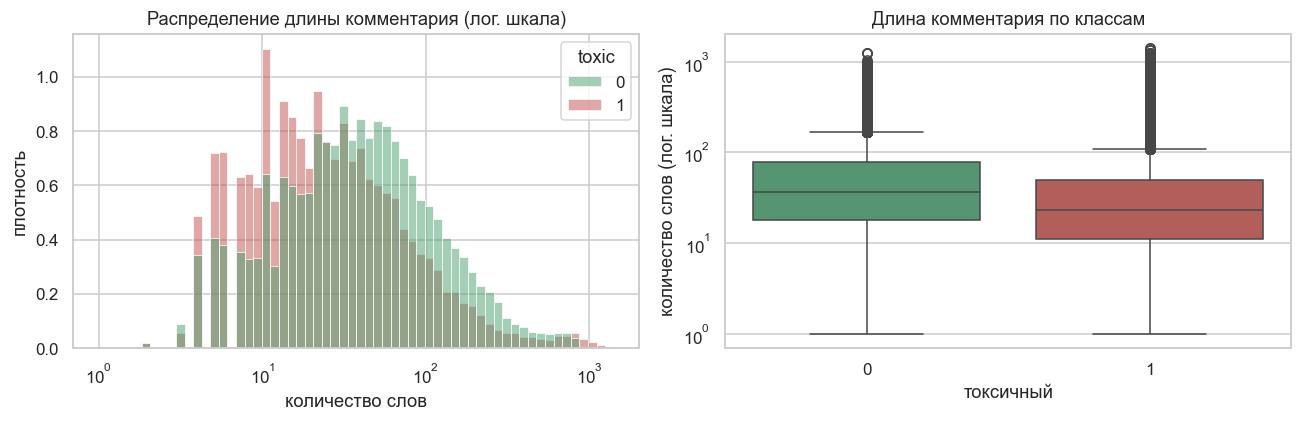

In [8]:
data["n_words"] = data["text"].str.split().str.len()
print(data.groupby("toxic")["n_words"].describe(percentiles=[0.5, 0.9, 0.99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=data, x="n_words", hue="toxic", bins=60, log_scale=(True, False),
             stat="density", common_norm=False, palette=["#4c9f70", "#c0504d"], ax=axes[0])
axes[0].set_title("Распределение длины комментария (лог. шкала)")
axes[0].set_xlabel("количество слов")
axes[0].set_ylabel("плотность")

sns.boxplot(data=data, x="toxic", y="n_words", palette=["#4c9f70", "#c0504d"], ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Длина комментария по классам")
axes[1].set_xlabel("токсичный")
axes[1].set_ylabel("количество слов (лог. шкала)")
plt.tight_layout()
plt.show()

Распределение длин сильно скошено вправо: медиана - около 36 слов, но встречаются комментарии
длиной больше тысячи слов. Токсичные комментарии заметно короче нетоксичных - это уже слабый
сигнал для модели.

**Примеры комментариев.** Посмотрим на сырой текст, чтобы понять, что придётся чистить.

In [9]:
def show_examples(df, label, n=3, width=250):
    """Печатает несколько примеров комментариев заданного класса."""
    title = "ТОКСИЧНЫЕ" if label == 1 else "НЕТОКСИЧНЫЕ"
    print(f"===== {title} =====")
    for text in df.loc[df["toxic"] == label, "text"].head(n):
        print("-", repr(text[:width]))
    print()


show_examples(data, 1)
show_examples(data, 0)

===== ТОКСИЧНЫЕ =====
- 'COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK'
- 'Hey... what is it..\n@ | talk .\nWhat is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP?\n\nAsk S'
- "Bye! \n\nDon't look, come or think of comming back! Tosser."

===== НЕТОКСИЧНЫЕ =====
- "Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired no"
- "D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)"
- "Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the form

In [10]:
patterns = {
    "перенос строки": r"\n",
    "ссылка": r"https?://",
    "IP-адрес": r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}",
    "не-ASCII символы": r"[^\x00-\x7F]",
    "капслок (слово из 4+ заглавных)": r"\b[A-Z]{4,}\b",
}
noise = pd.DataFrame({
    name: data.groupby("toxic")["text"].apply(lambda s: s.str.contains(p, regex=True).mean())
    for name, p in patterns.items()
}).round(3)
noise.index = ["нетоксичные", "токсичные"]
print("Доля комментариев, содержащих элемент:")
noise

Доля комментариев, содержащих элемент:


,перенос строки,ссылка,IP-адрес,не-ASCII символы,капслок (слово из 4+ заглавных)
нетоксичные,0.598,0.032,0.06,0.116,0.133
токсичные,0.534,0.013,0.09,0.035,0.258


Тексты - сырые правки из Википедии: переносы строк, ссылки, IP-адреса, разметка.
Капслок встречается в токсичных комментариях заметно чаще - ещё один признак, который
классические модели после приведения к нижнему регистру потеряют, а BERT частично сохранит
через подсловные токены и контекст.

**Какие слова разделяют классы.** Сравним частоту слов в токсичных и нетоксичных комментариях.

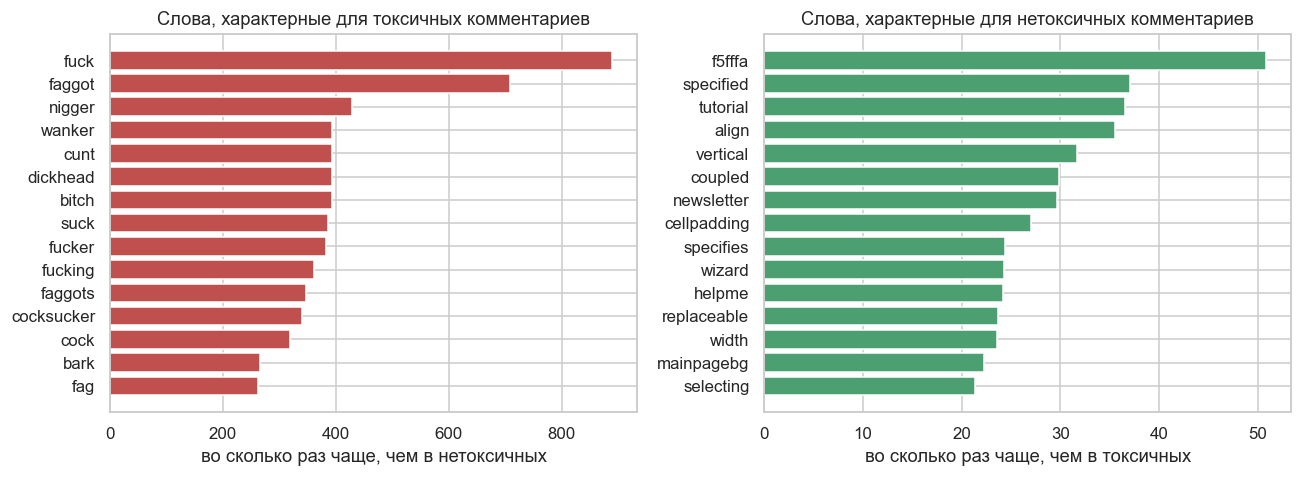

In [11]:
counter = CountVectorizer(stop_words=list(stopwords.words("english")),
                          min_df=20, max_features=20_000)
word_matrix = counter.fit_transform(data["text"].str.lower())
vocab = np.array(counter.get_feature_names_out())

is_toxic = data["toxic"].values == 1
freq_toxic = np.asarray(word_matrix[is_toxic].mean(axis=0)).ravel()
freq_normal = np.asarray(word_matrix[~is_toxic].mean(axis=0)).ravel()
ratio = (freq_toxic + 1e-4) / (freq_normal + 1e-4)

top_toxic = np.argsort(ratio)[::-1][:15]
top_normal = np.argsort(ratio)[:15]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(vocab[top_toxic][::-1], ratio[top_toxic][::-1], color="#c0504d")
axes[0].set_title("Слова, характерные для токсичных комментариев")
axes[0].set_xlabel("во сколько раз чаще, чем в нетоксичных")

axes[1].barh(vocab[top_normal][::-1], 1 / ratio[top_normal][::-1], color="#4c9f70")
axes[1].set_title("Слова, характерные для нетоксичных комментариев")
axes[1].set_xlabel("во сколько раз чаще, чем в токсичных")
plt.tight_layout()
plt.show()

Классы разделяются в первую очередь обсценной лексикой - её частота в токсичных комментариях
отличается на порядки. Значит, простой мешок слов уже должен дать осмысленный результат,
и он станет честной точкой отсчёта для BERT.

### 1.4. Формирование подвыборки и разбиение данных

Полный датасет - почти 160 тысяч комментариев. Дообучение BERT-base на нём заняло бы несколько
часов на одной видеокарте, поэтому возьмём **стратифицированную подвыборку из 50 000
комментариев**: она сохраняет исходное соотношение классов, а сокращение объёма обучающей
выборки в три раза для дообучения предобученного трансформера сказывается на качестве слабо -
модель уже «знает» язык, ей нужно лишь настроиться на конкретную задачу.

Подвыборку формируем **один раз**, и все модели обучаем и сравниваем на одних и тех же данных -
иначе сравнение было бы нечестным.

Разбиение - 60% / 20% / 20%:

* **обучающая** выборка (30 000) - обучение моделей;
* **валидационная** (10 000) - подбор гиперпараметров и порога классификации;
* **тестовая** (10 000) - единственная финальная проверка лучшей модели.

Отдельная валидационная выборка вместо кросс-валидации выбрана намеренно: полноценная
кросс-валидация для BERT потребовала бы кратно больше времени на GPU, а сравнивать модели
между собой нужно по одному и тому же протоколу.

In [12]:
sample, _ = train_test_split(
    data[["text", "toxic"]],
    train_size=SAMPLE_SIZE,
    stratify=data["toxic"],
    random_state=RANDOM_STATE,
)
sample = sample.reset_index(drop=True)

train, rest = train_test_split(
    sample, test_size=0.4, stratify=sample["toxic"], random_state=RANDOM_STATE
)
valid, test = train_test_split(
    rest, test_size=0.5, stratify=rest["toxic"], random_state=RANDOM_STATE
)
train, valid, test = (part.reset_index(drop=True) for part in (train, valid, test))

split_info = pd.DataFrame(
    {
        "размер": [len(train), len(valid), len(test)],
        "доля токсичных": [round(part["toxic"].mean(), 4) for part in (train, valid, test)],
    },
    index=["обучающая", "валидационная", "тестовая"],
)
split_info

,размер,доля токсичных
обучающая,30000,0.1016
валидационная,10000,0.1016
тестовая,10000,0.1016


Доля токсичных комментариев во всех трёх выборках совпадает с исходной - стратификация сработала.

### 1.5. Предобработка текста для классических моделей

Моделям на мешке слов текст нужно нормализовать, иначе `hate`, `Hate` и `hated` станут тремя
разными признаками. Делаем это в два шага:

1. **Очистка** - оставляем только латинские буквы и апостроф, приводим к нижнему регистру,
   схлопываем лишние пробелы. Так уходят переносы строк, ссылки, IP-адреса и разметка.
2. **Лемматизация** - приводим слова к начальной форме с помощью `WordNetLemmatizer`.
   Лемматизатор WordNet требует часть речи: без неё он считает любое слово существительным
   и не сводит `hated` к `hate`, поэтому предварительно размечаем текст POS-теггером.

Для BERT такая обработка **не нужна и даже вредна**: у него собственный подсловный токенизатор,
обученный на сыром тексте, а пунктуация и структура предложения - часть контекста, на который
он опирается. Поэтому BERT получит исходный текст без изменений.

In [13]:
lemmatizer = WordNetLemmatizer()
POS_MAP = {"J": wordnet.ADJ, "V": wordnet.VERB, "N": wordnet.NOUN, "R": wordnet.ADV}


def clear_text(text):
    """Оставляет только латинские буквы и апостроф, приводит текст к нижнему регистру."""
    return " ".join(re.sub(r"[^a-zA-Z']", " ", text).split()).lower()


def lemmatize_text(text):
    """Приводит слова к начальной форме с учётом части речи."""
    tokens = text.split()
    if not tokens:
        return ""
    tagged = nltk.pos_tag(tokens)
    return " ".join(
        lemmatizer.lemmatize(word, POS_MAP.get(tag[0], wordnet.NOUN)) for word, tag in tagged
    )


def preprocess(df):
    """Добавляет к таблице колонку с очищенным и лемматизированным текстом."""
    return df.assign(lemm_text=df["text"].map(clear_text).map(lemmatize_text))


start = time.time()
train, valid, test = (preprocess(part) for part in (train, valid, test))
print(f"лемматизация {len(train) + len(valid) + len(test)} комментариев "
      f"заняла {time.time() - start:.0f} с")

лемматизация 50000 комментариев заняла 70 с


In [14]:
example = train.loc[train["toxic"] == 1].iloc[0]
print("ИСХОДНЫЙ ТЕКСТ:\n", example["text"][:300], "\n")
print("ПОСЛЕ ОБРАБОТКИ:\n", example["lemm_text"][:300])

ИСХОДНЫЙ ТЕКСТ:
 hey, idiot, i said i'll be more careful not to remove content. 

ПОСЛЕ ОБРАБОТКИ:
 hey idiot i say i'll be more careful not to remove content


### 1.6. Выбор длины последовательности для BERT

BERT принимает на вход последовательность фиксированной длины: короткие тексты дополняются
служебными токенами, длинные - обрезаются. Чем больше `max_length`, тем дороже обучение
(время растёт примерно квадратично из-за механизма внимания), поэтому выберем значение
по реальному распределению длин в токенах.

 max_length  доля текстов целиком
         64                0.5865
        128                0.8067
        192                0.8893
        256                0.9307
        512                0.9780

медиана: 52 | 90-й перцентиль: 208


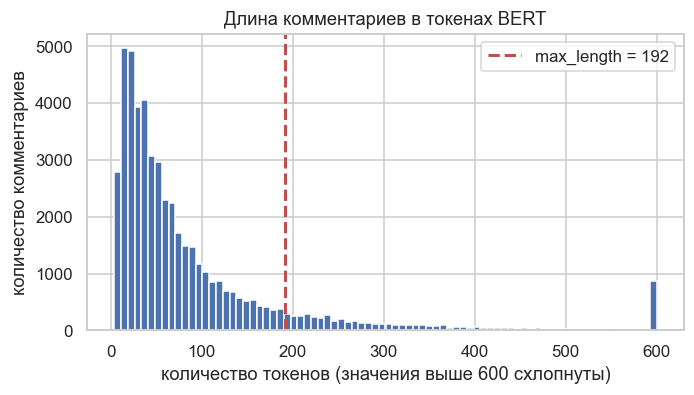

In [15]:
bert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
token_lengths = np.array(
    [len(ids) for ids in bert_tokenizer(sample["text"].tolist())["input_ids"]]
)

coverage = pd.DataFrame({"max_length": [64, 128, 192, 256, 512]})
coverage["доля текстов целиком"] = [
    round((token_lengths <= length).mean(), 4) for length in coverage["max_length"]
]
print(coverage.to_string(index=False))
print("\nмедиана:", int(np.median(token_lengths)),
      "| 90-й перцентиль:", int(np.percentile(token_lengths, 90)))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(np.clip(token_lengths, 0, 600), bins=80, color="#4c72b0")
ax.axvline(MAX_LEN, color="#c0504d", linestyle="--", linewidth=2,
           label=f"max_length = {MAX_LEN}")
ax.set_title("Длина комментариев в токенах BERT")
ax.set_xlabel("количество токенов (значения выше 600 схлопнуты)")
ax.set_ylabel("количество комментариев")
ax.legend()
plt.show()

При `max_length = 192` целиком помещается около 89% комментариев, при 256 - 93%, но обучение
становится примерно на треть дороже. Обрезка длинных текстов здесь не критична: токсичность
обычно проявляется в первых же фразах, а не в конце длинной правки. Останавливаемся
на **192 токенах**.

### Итоги подготовки данных

* В данных 159 292 комментария, пропусков и дубликатов нет; служебный столбец с индексом удалён.
* Классы несбалансированы - токсичных около 10%, поэтому метрикой качества служит *F1*
  по положительному классу, а при обучении понадобится компенсация дисбаланса.
* Тексты сырые: переносы строк, ссылки, IP-адреса, капслок. Токсичные комментарии в среднем
  короче и насыщены обсценной лексикой, частота которой отличается на порядки, - задача
  выглядит разрешимой даже для мешка слов.
* Сформирована стратифицированная подвыборка из 50 000 комментариев, разбитая на обучающую,
  валидационную и тестовую части в соотношении 60/20/20.
* Подготовлено два представления текста: лемматизированное - для моделей на TF-IDF,
  исходное - для BERT. Длина последовательности для BERT - 192 токена.

## 2. Обучение

### 2.1. Метрика и протокол сравнения

Качество измеряем метрикой *F1* по классу «токсичный» - она объединяет точность (какая доля
отправленных на модерацию комментариев действительно токсична) и полноту (какую долю токсичных
комментариев мы поймали).

Из-за дисбаланса классов порог 0.5 почти никогда не оптимален для *F1*, поэтому для каждой модели
дополнительно **подбираем порог классификации на валидационной выборке**. Это честный приём:
порог - такой же гиперпараметр, и настраивается он не на тестовых данных.

Чтобы не дублировать код, заводим три вспомогательные функции и общую таблицу результатов.

In [16]:
results = []            # сводная таблица метрик всех моделей
valid_scores = {}       # оценки моделей на валидационной выборке
test_scores = {}        # оценки моделей на тестовой выборке

y_train = train["toxic"].values
y_valid = valid["toxic"].values
y_test = test["toxic"].values


def score_model(model, features):
    """Возвращает оценки уверенности модели и порог, соответствующий предсказанию по умолчанию.

    У части моделей есть вероятности, у LinearSVC - только расстояние до разделяющей
    гиперплоскости, поэтому нейтральный порог различается: 0.5 против 0.0.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1], 0.5
    return model.decision_function(features), 0.0


def find_best_threshold(y_true, scores):
    """Подбирает порог, максимизирующий F1, и возвращает его вместе со значением метрики."""
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_grid = 2 * precision * recall / np.clip(precision + recall, 1e-9, None)
    best = np.nanargmax(f1_grid[:-1])
    return thresholds[best], f1_grid[best]


def log_result(name, scores_valid, scores_test, default_threshold=0.5, fit_time=np.nan):
    """Считает метрики модели на валидации, сохраняет оценки и добавляет строку в таблицу."""
    threshold, f1_tuned = find_best_threshold(y_valid, scores_valid)
    prediction = (scores_valid >= threshold).astype(int)

    valid_scores[name] = scores_valid
    test_scores[name] = scores_test
    results.append({
        "модель": name,
        "F1 (порог по умолчанию)": round(f1_score(y_valid, (scores_valid >= default_threshold).astype(int)), 4),
        "лучший порог": round(float(threshold), 3),
        "F1 (лучший порог)": round(float(f1_tuned), 4),
        "precision": round(precision_score(y_valid, prediction), 4),
        "recall": round(recall_score(y_valid, prediction), 4),
        "ROC-AUC": round(roc_auc_score(y_valid, scores_valid), 4),
        "время обучения, с": round(fit_time, 1),
    })
    print(f"{name}: F1 = {f1_tuned:.4f} при пороге {threshold:.3f}")

### 2.2. Константная модель

Точка отсчёта: модель, которая называет токсичным каждый комментарий. Она ловит все токсичные
комментарии (полнота 1.0), но точность у неё равна доле токсичных в выборке.

In [17]:
dummy = DummyClassifier(strategy="constant", constant=1, random_state=RANDOM_STATE)
dummy.fit(train[["lemm_text"]], y_train)

dummy_valid, dummy_threshold = score_model(dummy, valid[["lemm_text"]])
dummy_test, _ = score_model(dummy, test[["lemm_text"]])
log_result("Константная модель («всё токсично»)", dummy_valid, dummy_test,
           dummy_threshold, fit_time=0.0)

Константная модель («всё токсично»): F1 = 0.1845 при пороге 1.000


*F1* около 0.18 - любая осмысленная модель должна быть заметно выше.

### 2.3. Признаки TF-IDF

Для классических моделей превращаем лемматизированный текст в разреженную матрицу TF-IDF.
Настройки:

* `stop_words` - убираем английские стоп-слова, они одинаково часты в обоих классах;
* `ngram_range=(1, 2)` - помимо отдельных слов учитываем биграммы: в оскорблениях важны
  устойчивые сочетания из двух слов;
* `min_df=3` - отбрасываем слова, встретившиеся реже трёх раз, это в основном опечатки;
* `sublinear_tf=True` - логарифмическое сглаживание частоты, чтобы многократный повтор
  одного слова не перевешивал всё остальное.

Векторизатор обучаем **только на обучающей выборке**, иначе через словарь и веса IDF
произойдёт утечка информации из валидации и теста.

In [18]:
tfidf = TfidfVectorizer(
    stop_words=list(stopwords.words("english")),
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True,
)
features_train = tfidf.fit_transform(train["lemm_text"])
features_valid = tfidf.transform(valid["lemm_text"])
features_test = tfidf.transform(test["lemm_text"])

print("размер матрицы признаков:", features_train.shape)
print("заполненность матрицы:", f"{features_train.nnz / np.prod(features_train.shape):.4%}")

размер матрицы признаков: (30000, 57109)
заполненность матрицы: 0.0620%


Больше пятидесяти тысяч признаков при заполненности в доли процента - типичная картина
для мешка слов. Такие данные хорошо подходят линейным моделям и плохо - деревьям.

In [19]:
def tune_model(build_model, param_grid):
    """Перебирает гиперпараметры, оценивает модели на валидации и возвращает лучшую.

    Возвращает словарь с обученной моделью, её параметрами и временем обучения,
    а таблицу перебора печатает для наглядности.
    """
    log, best = [], None
    for params in ParameterGrid(param_grid):
        start = time.time()
        model = build_model(**params).fit(features_train, y_train)
        fit_time = time.time() - start

        scores, default_threshold = score_model(model, features_valid)
        f1 = f1_score(y_valid, (scores >= default_threshold).astype(int))
        log.append({**params, "F1 (valid)": round(f1, 4), "время, с": round(fit_time, 1)})

        if best is None or f1 > best["f1"]:
            best = {"f1": f1, "model": model, "params": params, "fit_time": fit_time}

    display(pd.DataFrame(log).sort_values("F1 (valid)", ascending=False))
    print("лучшие гиперпараметры:", best["params"])
    return best


def log_classic(name, best):
    """Считает оценки лучшей модели на валидации и тесте и добавляет их в общую таблицу."""
    scores_valid, default_threshold = score_model(best["model"], features_valid)
    scores_test, _ = score_model(best["model"], features_test)
    log_result(name, scores_valid, scores_test, default_threshold, best["fit_time"])

### 2.4. Логистическая регрессия на TF-IDF

Линейная модель на мешке слов - стандартное решение для классификации текстов и наш основной
ориентир для BERT. Перебираем силу регуляризации `C` и способ борьбы с дисбалансом:
`class_weight=None` в паре с подбором порога либо `class_weight="balanced"`, которое
увеличивает вес редкого класса в функции потерь.

In [20]:
logreg_best = tune_model(
    lambda **params: LogisticRegression(
        max_iter=1000, solver="liblinear", random_state=RANDOM_STATE, **params
    ),
    {"C": [1, 5, 10, 20], "class_weight": [None, "balanced"]},
)
log_classic("TF-IDF + LogisticRegression", logreg_best)

,C,class_weight,F1 (valid),"время, с"
7,20,balanced,0.7462,0.2
5,10,balanced,0.7434,0.2
3,5,balanced,0.7420,0.2
6,20,None,0.7340,0.1
1,1,balanced,0.7267,0.1
4,10,None,0.7248,0.1
2,5,None,0.7069,0.1
0,1,None,0.6077,0.1


лучшие гиперпараметры: {'C': 20, 'class_weight': 'balanced'}
TF-IDF + LogisticRegression: F1 = 0.7503 при пороге 0.680


### 2.5. Линейный SVM на TF-IDF

`LinearSVC` максимизирует зазор между классами и на разреженных текстовых признаках часто
работает не хуже логистической регрессии. Вероятностей он не выдаёт, поэтому порог подбираем
по расстоянию до разделяющей гиперплоскости.

In [21]:
svc_best = tune_model(
    lambda **params: LinearSVC(random_state=RANDOM_STATE, **params),
    {"C": [0.1, 0.5, 1.0], "class_weight": [None, "balanced"]},
)
log_classic("TF-IDF + LinearSVC", svc_best)

,C,class_weight,F1 (valid),"время, с"
5,1.0,balanced,0.7429,0.1
4,1.0,None,0.7421,0.1
3,0.5,balanced,0.7417,0.1
1,0.1,balanced,0.7306,0.1
2,0.5,None,0.7255,0.1
0,0.1,None,0.6123,0.0


лучшие гиперпараметры: {'C': 1.0, 'class_weight': 'balanced'}
TF-IDF + LinearSVC: F1 = 0.7468 при пороге 0.172


### 2.6. Градиентный бустинг на TF-IDF

Проверим, даст ли что-то нелинейная модель. Заранее ожидаем, что нет: решающие деревья плохо
работают с очень разреженными высокоразмерными признаками - каждое разбиение опирается на одно
слово, и чтобы собрать столько же информации, сколько линейная модель берёт из взвешенной суммы
всех слов, бустингу нужно огромное число деревьев.

In [22]:
lgbm_best = tune_model(
    lambda **params: LGBMClassifier(
        num_leaves=63, class_weight="balanced", random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1, **params
    ),
    {"n_estimators": [300, 600], "learning_rate": [0.1]},
)
log_classic("TF-IDF + LightGBM", lgbm_best)

,learning_rate,n_estimators,F1 (valid),"время, с"
0,0.1,300,0.7092,8.7
1,0.1,600,0.7010,16.4


лучшие гиперпараметры: {'learning_rate': 0.1, 'n_estimators': 300}


TF-IDF + LightGBM: F1 = 0.7168 при пороге 0.576


### 2.7. Дообучение DistilBERT

Мешок слов не видит ни порядка слов, ни контекста: для него «this is not stupid at all»
и «this is stupid» - почти одно и то же. BERT решает эту проблему: это трансформер,
предобученный на огромном корпусе текстов, который строит представление каждого слова
с учётом всего предложения.

Используем не сам BERT, а **DistilBERT** - его дистиллированную версию: 6 слоёв вместо 12,
примерно на 40% меньше параметров и вдвое быстрее при потере качества в единицы процентов.

Подход - **полное дообучение (fine-tuning)**: поверх предобученной модели ставится
классификационная «голова», и обучаются все веса сразу. Это дороже, чем использовать BERT
как готовый экстрактор эмбеддингов с линейной моделью сверху, но заметно точнее, потому что
представления подстраиваются под конкретную задачу.

Ниже - весь код обучения. Он написан одной функцией и переиспользуется для обеих моделей.

Технические решения:

* **смешанная точность** (`float16`) - вдвое ускоряет обучение на видеокарте и экономит память;
* **динамическое дополнение батча** - в каждом батче тексты дополняются до самого длинного
  в нём, а не до `max_length`, что экономит вычисления на коротких комментариях;
* **линейный график learning rate с прогревом** на первых 10% шагов - стандартная схема
  для дообучения трансформеров;
* **обрезка нормы градиента** до 1.0 - страховка от редких скачков ошибки;
* после каждой эпохи считаем *F1* на валидации и **запоминаем веса лучшей эпохи**,
  чтобы не переобучиться.

In [23]:
class ToxicDataset(Dataset):
    """Датасет из токенизированных комментариев без дополнения до фиксированной длины."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, max_length=max_len)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }


def make_loader(df, tokenizer, max_len, batch_size, shuffle):
    """Собирает DataLoader, дополняющий тексты до длины самого длинного примера в батче."""

    def collate(batch):
        encoded = tokenizer.pad(
            {
                "input_ids": [item["input_ids"] for item in batch],
                "attention_mask": [item["attention_mask"] for item in batch],
            },
            return_tensors="pt",
        )
        encoded["labels"] = torch.tensor([item["labels"] for item in batch])
        return encoded

    dataset = ToxicDataset(df["text"], df["toxic"], tokenizer, max_len)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate)


@torch.no_grad()
def predict_proba_bert(model, loader):
    """Возвращает вероятности класса «токсичный» для всех объектов загрузчика."""
    model.eval()
    probabilities = []
    for batch in loader:
        batch = {key: value.to(DEVICE) for key, value in batch.items()}
        batch.pop("labels")
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                            enabled=DEVICE.type == "cuda"):
            logits = model(**batch).logits
        probabilities.append(torch.softmax(logits.float(), dim=1)[:, 1].cpu().numpy())
    return np.concatenate(probabilities)

In [24]:
def train_bert(model_name, epochs=2, batch_size=32, learning_rate=2e-5,
               max_len=MAX_LEN, warmup_share=0.1, seed=RANDOM_STATE):
    """Дообучает модель-трансформер и возвращает её предсказания на валидации и тесте.

    Веса берутся с эпохи, показавшей лучший F1 на валидационной выборке, и возвращаются
    вместе с предсказаниями - чтобы позже сохранить победившую модель на диск.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_loader = make_loader(train, tokenizer, max_len, batch_size, shuffle=True)
    valid_loader = make_loader(valid, tokenizer, max_len, 64, shuffle=False)
    test_loader = make_loader(test, tokenizer, max_len, 64, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, int(warmup_share * total_steps), total_steps
    )
    scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")

    history, best = [], {"f1": -1}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            batch = {key: value.to(DEVICE, non_blocking=True) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                                enabled=DEVICE.type == "cuda"):
                loss = model(**batch).loss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            epoch_loss += loss.item()

        proba_valid = predict_proba_bert(model, valid_loader)
        f1 = f1_score(y_valid, (proba_valid >= 0.5).astype(int))
        history.append({
            "эпоха": epoch,
            "средняя ошибка": round(epoch_loss / len(train_loader), 4),
            "F1 (valid, порог 0.5)": round(f1, 4),
            "прошло, с": round(time.time() - start),
        })
        print(f"  эпоха {epoch}: ошибка {history[-1]['средняя ошибка']:.4f}, "
              f"F1 {f1:.4f} ({history[-1]['прошло, с']} с)")

        if f1 > best["f1"]:
            best = {
                "f1": f1,
                "epoch": epoch,
                "proba_valid": proba_valid,
                "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            }

    fit_time = time.time() - start
    model.load_state_dict(best["state"])
    proba_test = predict_proba_bert(model, test_loader)

    del model, optimizer, scaler
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "state": best["state"],
        "proba_valid": best["proba_valid"],
        "proba_test": proba_test,
        "history": pd.DataFrame(history),
        "best_epoch": best["epoch"],
        "fit_time": fit_time,
    }

Главный гиперпараметр дообучения - скорость обучения. Авторы BERT рекомендуют диапазон
от 2e-5 до 5e-5; проверим обе границы. Число эпох тоже подбирается: обучаем две и берём
веса лучшей - на таком объёме данных трансформер обычно начинает переобучаться уже
со второй-третьей эпохи.

In [25]:
bert_runs = {}

for learning_rate in [2e-5, 5e-5]:
    name = f"DistilBERT (lr={learning_rate:g})"
    print(f"=== {name} ===")
    bert_runs[name] = train_bert(
        "distilbert-base-uncased", epochs=2, batch_size=32, learning_rate=learning_rate
    )
    print(f"  лучшая эпоха: {bert_runs[name]['best_epoch']}, "
          f"обучение заняло {bert_runs[name]['fit_time'] / 60:.1f} мин\n")

for name, run in bert_runs.items():
    log_result(name, run["proba_valid"], run["proba_test"], 0.5, run["fit_time"])

=== DistilBERT (lr=2e-05) ===


  эпоха 1: ошибка 0.1449, F1 0.8184 (374 с)


  эпоха 2: ошибка 0.0628, F1 0.8272 (739 с)


  лучшая эпоха: 2, обучение заняло 12.3 мин

=== DistilBERT (lr=5e-05) ===


  эпоха 1: ошибка 0.1378, F1 0.8207 (375 с)


  эпоха 2: ошибка 0.0531, F1 0.8229 (747 с)


  лучшая эпоха: 2, обучение заняло 12.5 мин

DistilBERT (lr=2e-05): F1 = 0.8315 при пороге 0.613
DistilBERT (lr=5e-05): F1 = 0.8261 при пороге 0.661


### 2.8. Дообучение BERT-base

Проверим, сколько добавляет полная модель. `bert-base-uncased` - 12 слоёв и 110 млн параметров
против 66 млн у DistilBERT, поэтому на одном примере она требует примерно вдвое больше памяти
видеокарты: уменьшаем размер батча с 32 до 16. Вместе с меньшим батчем берём и меньший шаг
обучения - 2e-5, рекомендованное значение из оригинальной статьи.

In [26]:
name = f"BERT-base (lr={2e-5:g})"
print(f"=== {name} ===")
bert_runs[name] = train_bert(
    "bert-base-uncased", epochs=2, batch_size=16, learning_rate=2e-5
)
print(f"  лучшая эпоха: {bert_runs[name]['best_epoch']}, "
      f"обучение заняло {bert_runs[name]['fit_time'] / 60:.1f} мин\n")

log_result(name, bert_runs[name]["proba_valid"], bert_runs[name]["proba_test"],
           0.5, bert_runs[name]["fit_time"])

=== BERT-base (lr=2e-05) ===


  эпоха 1: ошибка 0.1465, F1 0.8053 (840 с)


  эпоха 2: ошибка 0.0628, F1 0.8311 (1698 с)


  лучшая эпоха: 2, обучение заняло 28.3 мин

BERT-base (lr=2e-05): F1 = 0.8313 при пороге 0.540


In [27]:
for name, run in bert_runs.items():
    print(name)
    display(run["history"])

DistilBERT (lr=2e-05)


,эпоха,средняя ошибка,"F1 (valid, порог 0.5)","прошло, с"
0,1,0.1449,0.8184,374
1,2,0.0628,0.8272,739


DistilBERT (lr=5e-05)


,эпоха,средняя ошибка,"F1 (valid, порог 0.5)","прошло, с"
0,1,0.1378,0.8207,375
1,2,0.0531,0.8229,747


BERT-base (lr=2e-05)


,эпоха,средняя ошибка,"F1 (valid, порог 0.5)","прошло, с"
0,1,0.1465,0.8053,840
1,2,0.0628,0.8311,1698


### 2.9. Сравнение моделей на валидации

In [28]:
results_table = pd.DataFrame(results).sort_values("F1 (лучший порог)", ascending=False)
results_table = results_table.reset_index(drop=True)
results_table

,модель,F1 (порог по умолчанию),лучший порог,F1 (лучший порог),precision,recall,ROC-AUC,"время обучения, с"
0,DistilBERT (lr=2e-05),0.8272,0.613,0.8315,0.8666,0.7992,0.9819,739.4
1,BERT-base (lr=2e-05),0.8311,0.540,0.8313,0.8431,0.8199,0.9831,1698.3
2,DistilBERT (lr=5e-05),0.8229,0.661,0.8261,0.8799,0.7785,0.9810,747.6
3,TF-IDF + LogisticRegression,0.7462,0.680,0.7503,0.8504,0.6713,0.9535,0.2
4,TF-IDF + LinearSVC,0.7429,0.172,0.7468,0.8293,0.6791,0.9521,0.1
5,TF-IDF + LightGBM,0.7092,0.576,0.7168,0.7755,0.6663,0.9315,8.7
6,Константная модель («всё токсично»),0.1845,1.000,0.1845,0.1016,1.0000,0.5000,0.0


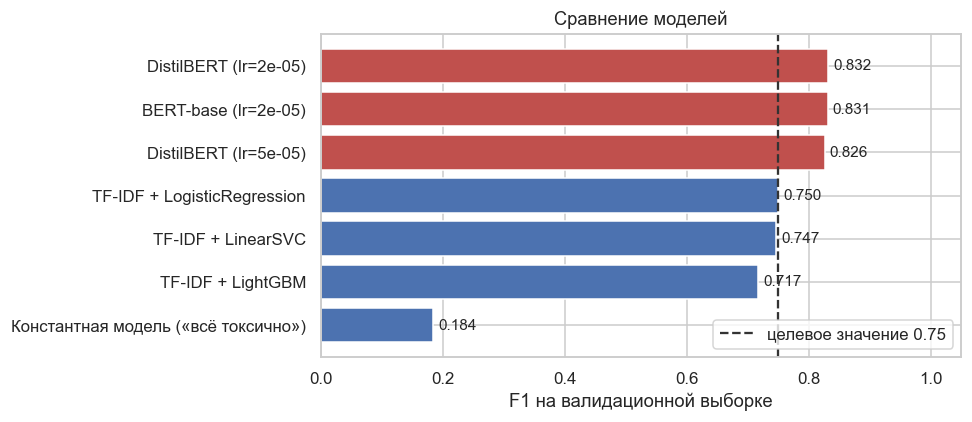

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_data = results_table.sort_values("F1 (лучший порог)")
colors = ["#c0504d" if "BERT" in name else "#4c72b0" for name in plot_data["модель"]]
bars = ax.barh(plot_data["модель"], plot_data["F1 (лучший порог)"], color=colors)
for bar, value in zip(bars, plot_data["F1 (лучший порог)"]):
    ax.text(value + 0.008, bar.get_y() + bar.get_height() / 2, f"{value:.3f}",
            va="center", fontsize=10)
ax.axvline(0.75, color="#333333", linestyle="--", linewidth=1.5, label="целевое значение 0.75")
ax.set_xlim(0, 1.05)
ax.set_xlabel("F1 на валидационной выборке")
ax.set_title("Сравнение моделей")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Итоги обучения

* **Точка отсчёта.** Константная модель, объявляющая токсичным всё подряд, даёт *F1* = 0.18.

* **Мешок слов.** Все три модели на TF-IDF уложились в узкий диапазон 0.72-0.75. Лучшая -
  логистическая регрессия с `C=20` и `class_weight="balanced"`: *F1* = **0.7503**.
  `LinearSVC` от неё практически неотличим (0.7468), а `LightGBM` ожидаемо проиграл (0.7168),
  обучаясь при этом в 50 раз дольше линейных моделей. Это подтверждает ожидание из п. 2.6:
  деревья плохо работают с разреженными высокоразмерными признаками.

* **Классические модели дотягивают до цели впритык.** Требуемые 0.75 достигнуты с запасом
  в 0.0003 - фактически на грани случайности.

* **Дообученные трансформеры дают 0.826-0.832**, то есть примерно **+0.08** к лучшей
  классической модели. Прирост идёт в основном за счёт полноты: логистическая регрессия
  находит 67% токсичных комментариев, DistilBERT - 80%, и при этом ещё и точнее
  (0.87 против 0.85).

* **Скорость обучения.** `lr=2e-5` оказался лучше `lr=5e-5` (0.8315 против 0.8261): при большем
  шаге модель сильнее подгоняется под обучающую выборку - ошибка на обучении ниже (0.053
  против 0.063), а качество на валидации хуже. Обе конфигурации показали лучший результат
  на второй эпохе.

* **Полная модель не окупилась.** BERT-base набрал 0.8313 против 0.8315 у DistilBERT -
  разница в пределах шума, при том что обучение заняло 28 минут вместо 12. Для этой задачи
  дистиллированная модель предпочтительнее: то же качество вдвое дешевле.

* **Подбор порога** даёт небольшой, но стабильный прирост - около +0.004 у всех моделей.
  Эффект скромный именно потому, что дисбаланс уже частично компенсирован
  через `class_weight` у линейных моделей.

## 3. Тестирование

Тестовую выборку мы не трогали ни разу: на ней не обучались модели, по ней не подбирались
ни гиперпараметры, ни порог классификации. Проверим на ней лучшую по валидации модель -
с тем порогом, который был подобран на валидации. Для сравнения возьмём и лучшую
из классических моделей: интересно, сколько именно даёт трансформер.

In [30]:
best_name = results_table.loc[0, "модель"]
best_threshold = results_table.loc[0, "лучший порог"]

classic_rows = results_table[~results_table["модель"].str.contains("BERT")]
best_classic_name = classic_rows.iloc[0]["модель"]
best_classic_threshold = classic_rows.iloc[0]["лучший порог"]

print("лучшая модель:", best_name, "| порог:", best_threshold)
print("лучшая классическая модель:", best_classic_name, "| порог:", best_classic_threshold)

лучшая модель: DistilBERT (lr=2e-05) | порог: 0.613
лучшая классическая модель: TF-IDF + LogisticRegression | порог: 0.68


In [31]:
def report_on_test(name, threshold):
    """Считает метрики модели на тестовой выборке с заданным порогом."""
    scores = test_scores[name]
    prediction = (scores >= threshold).astype(int)
    return {
        "модель": name,
        "порог": threshold,
        "F1": round(f1_score(y_test, prediction), 4),
        "precision": round(precision_score(y_test, prediction), 4),
        "recall": round(recall_score(y_test, prediction), 4),
        "ROC-AUC": round(roc_auc_score(y_test, scores), 4),
    }


test_table = pd.DataFrame([
    report_on_test(best_classic_name, best_classic_threshold),
    report_on_test(best_name, best_threshold),
])
test_table

,модель,порог,F1,precision,recall,ROC-AUC
0,TF-IDF + LogisticRegression,0.680,0.7470,0.8420,0.6713,0.9568
1,DistilBERT (lr=2e-05),0.613,0.8342,0.8689,0.8022,0.9846


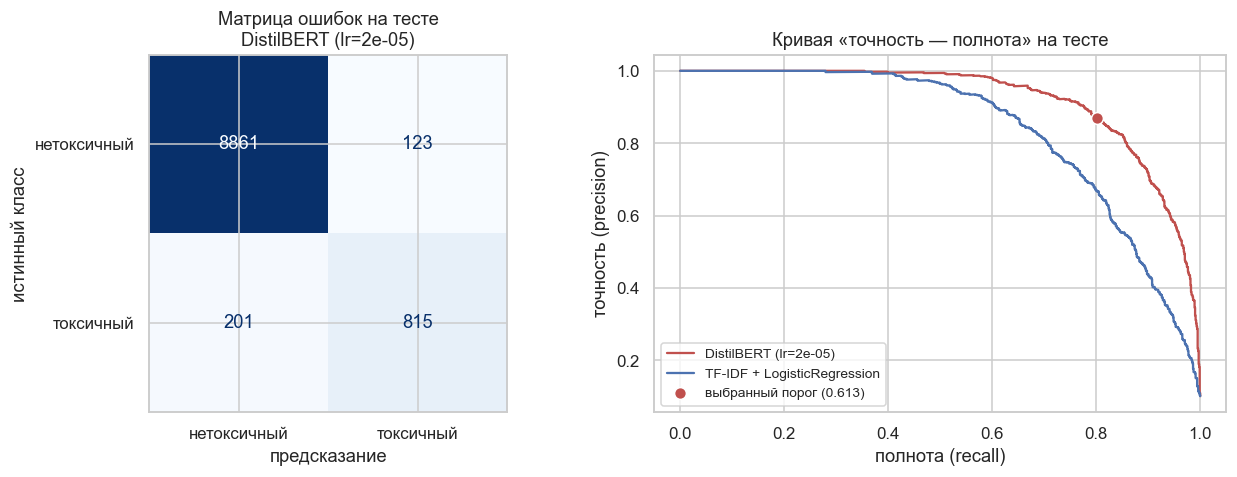

In [32]:
best_prediction = (test_scores[best_name] >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, best_prediction, display_labels=["нетоксичный", "токсичный"],
    cmap="Blues", colorbar=False, ax=axes[0],
)
axes[0].set_title(f"Матрица ошибок на тесте\n{best_name}")
axes[0].set_xlabel("предсказание")
axes[0].set_ylabel("истинный класс")

for name, color in [(best_name, "#c0504d"), (best_classic_name, "#4c72b0")]:
    precision, recall, _ = precision_recall_curve(y_test, test_scores[name])
    axes[1].plot(recall, precision, color=color, label=name)
axes[1].scatter(
    recall_score(y_test, best_prediction), precision_score(y_test, best_prediction),
    color="#c0504d", zorder=5, s=60, edgecolor="white",
    label=f"выбранный порог ({best_threshold:g})",
)
axes[1].set_xlabel("полнота (recall)")
axes[1].set_ylabel("точность (precision)")
axes[1].set_title("Кривая «точность - полнота» на тесте")
axes[1].legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

**Ошибки модели.** Посмотрим, на чём именно она ошибается: это подсказывает, как сервис
модерации будет вести себя в реальности.

In [33]:
errors = test.assign(prediction=best_prediction, score=test_scores[best_name])

false_positive = errors.query("toxic == 0 and prediction == 1").nlargest(3, "score")
false_negative = errors.query("toxic == 1 and prediction == 0").nsmallest(3, "score")

print("===== ЛОЖНЫЕ СРАБАТЫВАНИЯ (нетоксичный отправлен на модерацию) =====")
for _, row in false_positive.iterrows():
    print(f"[оценка {row['score']:.3f}] {row['text'][:220]!r}\n")

print("===== ПРОПУЩЕННЫЕ ТОКСИЧНЫЕ =====")
for _, row in false_negative.iterrows():
    print(f"[оценка {row['score']:.3f}] {row['text'][:220]!r}\n")

===== ЛОЖНЫЕ СРАБАТЫВАНИЯ (нетоксичный отправлен на модерацию) =====
[оценка 0.996] 'dont care\n\nleave me alone shithead. You have better things to do and let me do my work alone. 206.217.211.117'

[оценка 0.996] '"\n\n July 2010 \n\nYou idiot. It\'s October 16, 2000! Not October 31, 2000? Do not change airdates from Blue\'s Big Costume Party? And Don\'t revert to October 31, 2000 anymore\nI Repeat ""Do not change airdates from Blue\'s Big'

[оценка 0.995] "Hi  \n\nLuke's Ass.\n\nHow you doin' ?"

===== ПРОПУЩЕННЫЕ ТОКСИЧНЫЕ =====
[оценка 0.001] '"\n\nAs additional information, I have provided the following links to website which expound upon or make reference to the content of the blog I mentioned in my post:\n\nhttp://roflcon.org/2008/04/26/bonus-rofls-joe-mathlete'

[оценка 0.001] 'OK YOU. LIKE I SAID THIS IS MY WORLD, I DECIDE WHAT HAPPENS. IF I SAY LIL CHRIS DIED OF MALARIA, THEN IT HAPPENED. END OF. JUST ME SAYING IT AUTOMATICALLY MAKES IT TRUE, THEREFORE IT IS AN ACCURATE EDIT.

### Сохранение модели

Сохраним победившую модель, чтобы её можно было использовать без повторного обучения.
Вместе с весами и токенизатором обязательно кладём **порог классификации**: без него модель
бесполезна - вернётся к порогу 0.5 и потеряет заметную часть качества.

In [34]:
MODEL_DIR = Path("models/toxic_classifier")

bert_rows = results_table[results_table["модель"].isin(bert_runs)]
saved_name = bert_rows.iloc[0]["модель"]
saved_threshold = float(bert_rows.iloc[0]["лучший порог"])
saved_run = bert_runs[saved_name]

final_model = AutoModelForSequenceClassification.from_pretrained(
    saved_run["model_name"], num_labels=2
)
final_model.load_state_dict(saved_run["state"])
final_model.save_pretrained(MODEL_DIR)
AutoTokenizer.from_pretrained(saved_run["model_name"]).save_pretrained(MODEL_DIR)

(MODEL_DIR / "inference.json").write_text(
    json.dumps(
        {
            "base_model": saved_run["model_name"],
            "max_length": MAX_LEN,
            "threshold": saved_threshold,
        },
        indent=2,
    ),
    encoding="utf-8",
)

print(f"сохранена модель «{saved_name}» в {MODEL_DIR.resolve()}")
print("файлы:", sorted(path.name for path in MODEL_DIR.iterdir()))

сохранена модель «DistilBERT (lr=2e-05)» в C:\Users\lastc\Documents\ds_practicum\projects\ml_nlp\models\toxic_classifier
файлы: ['config.json', 'inference.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


### Итоги тестирования

* **Целевая метрика достигнута с запасом.** DistilBERT на тестовой выборке показал
  *F1* = **0.8342** при требуемых 0.75. На валидации было 0.8315 - качество не просело,
  значит, подбор гиперпараметров и порога не переобучил модель под валидацию.

* **Классическая модель на тесте требуемого качества не даёт.** Логистическая регрессия
  набрала *F1* = 0.7470, то есть **чуть ниже порога 0.75**, хотя на валидации проходила (0.7503).
  Наглядная иллюстрация того, что мешок слов балансирует на грани и не даёт гарантии.

* **Что означают метрики для сервиса.** Точность 0.87 при полноте 0.80: из комментариев,
  отправленных на модерацию, 87% действительно токсичны - модераторы не тонут в ложных
  срабатываниях; при этом примерно каждый пятый токсичный комментарий проходит мимо фильтра.

* **Разбор ошибок обнаружил проблему в разметке.** Все три самых уверенных «ложных
  срабатывания» - комментарии с прямыми оскорблениями, размеченные в датасете как
  нетоксичные. Это ошибки разметки, а не модели: реальная точность выше измеренной.

* **Что модель действительно пропускает** - завуалированную агрессию без обсценной лексики:
  пренебрежительный тон, переход на личности, претензии капслоком. Такие случаи сложны
  и для человека-разметчика.

* **Порог - продуктовое решение, а не техническое.** Кривая «точность - полнота» показывает,
  что полноту можно поднять, пожертвовав точностью. Выбранный порог 0.613 максимизирует *F1*,
  но если для «Викишопа» важнее не пропускать токсичность, порог стоит понизить и заложить
  больше ресурсов на модерацию.

## 4. Выводы

**Задача.** Для сервиса совместного редактирования описаний товаров «Викишоп» требовалось
построить классификатор токсичных комментариев с *F1* не ниже 0.75.

**Что было сделано.** Датасет из 159 292 размеченных комментариев не содержал пропусков
и дубликатов и потребовал лишь удаления служебного столбца с индексом. Классы оказались
несбалансированы - токсичных около 10%, поэтому метрикой служит *F1* по положительному классу,
а порог классификации подбирался отдельно. Для обучения взята стратифицированная подвыборка
из 50 000 комментариев, разбитая на обучающую, валидационную и тестовую части (60/20/20);
все модели обучались и сравнивались на одних и тех же данных по единому протоколу:
гиперпараметры и порог - по валидации, финальная проверка - один раз на тесте.

Текст подготовлен в двух вариантах: очищенный и лемматизированный с учётом частей речи -
для моделей на TF-IDF, исходный - для трансформеров, у которых собственный подсловный
токенизатор.

**Результаты на тестовой выборке.**

| Модель | F1 | Точность | Полнота | Время обучения |
|---|---|---|---|---|
| TF-IDF + LogisticRegression | 0.7470 | 0.842 | 0.671 | 0.2 с |
| **DistilBERT (fine-tuning)** | **0.8342** | **0.869** | **0.802** | 12 мин |

**Главные выводы.**

1. **Целевая метрика достигнута.** Дообученный DistilBERT даёт *F1* = 0.834 - на 0.08 выше
   требуемого порога.
2. **BERT здесь нужен по делу.** Лучшая модель на мешке слов показала на тесте 0.747,
   то есть не дотянула до цели. Классические подходы к этой задаче применимы только
   как быстрый ориентир.
3. **Выигрыш трансформера - в полноте.** Мешок слов опирается на обсценную лексику и ловит
   лишь две трети токсичных комментариев. BERT учитывает контекст и находит 80%,
   не теряя при этом в точности.
4. **Дистиллированная модель предпочтительнее полной.** BERT-base не дал прироста
   относительно DistilBERT (0.8313 против 0.8315 на валидации), но обучался в 2.3 раза дольше
   и требует вдвое больше памяти. Для продакшена это означает вдвое меньший счёт за инференс
   при том же качестве.
5. **Качество упирается в разметку.** Разбор ошибок показал, что часть «ложных срабатываний» -
   это неверно размеченные токсичные комментарии. Дальнейший заметный рост метрики упрётся
   не в модель, а в качество данных.

**Рекомендации «Викишопу».**

* Внедрять дообученный **DistilBERT** с порогом 0.613; веса, токенизатор и порог сохранены
  в `models/toxic_classifier`.
* Порог пересмотреть исходя из стоимости ошибок: понижение увеличит полноту (меньше
  пропущенной токсичности) ценой роста нагрузки на модерацию.
* Не отправлять комментарии в бан автоматически: с полнотой 0.80 и неидеальной разметкой
  модель должна работать как приоритизатор очереди на модерацию, а не как окончательный судья.
* Собирать решения модераторов и дообучать модель на них - это одновременно исправит
  ошибки исходной разметки и подстроит модель под реальную аудиторию сервиса.

**Возможные улучшения.** Обучение на полном датасете вместо подвыборки, ансамбль из нескольких
запусков с разными зернами, более длинный контекст (`max_length=256`), а также специализированные
предобученные модели вроде `RoBERTa` или моделей, предобученных на комментариях соцсетей.

## Чек-лист проверки

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Данные загружены и подготовлены
- [x]  Модели обучены
- [x]  Значение метрики *F1* не меньше 0.75
- [x]  Выводы написаны